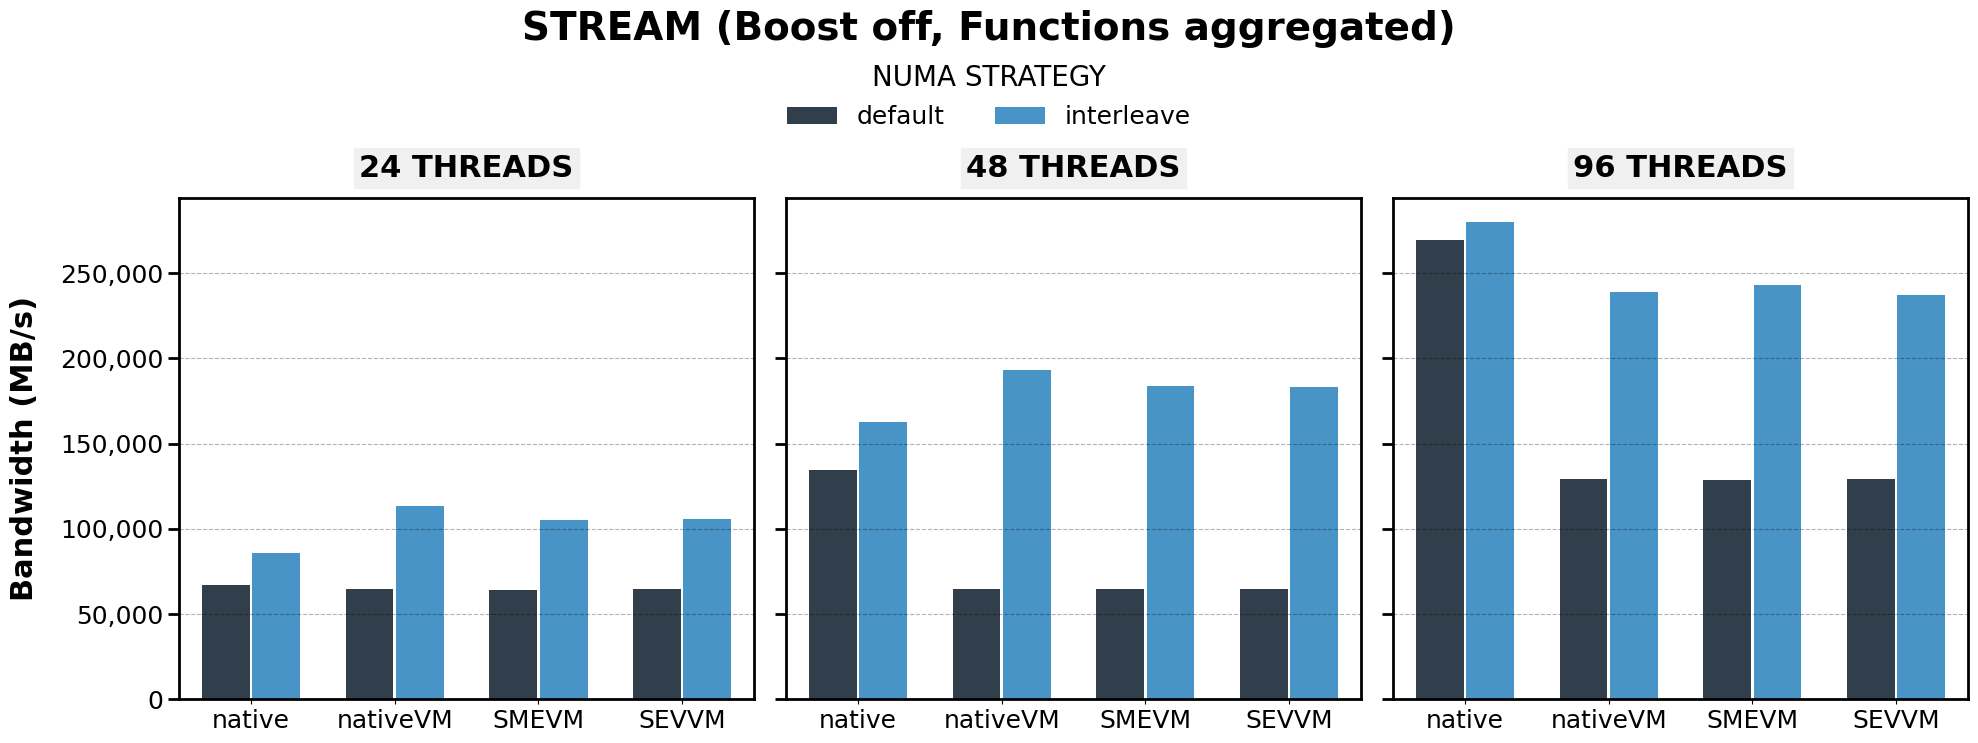

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Daten laden und vorbereiten
df = pd.read_csv("stream_results.csv")
env_order = ["native", "nativeVM", "SMEVM", "SEVVM"]
df["Env"] = pd.Categorical(df["Env"], categories=env_order, ordered=True)
df_plot = df[df["Boost"] == "off"].copy()

# 2. Plot Setup - 1x3 Layout für die Slide
fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

# Haupttitel (Ganz oben)
fig.suptitle("STREAM (Boost off, Functions aggregated)", 
             fontsize=28, fontweight='bold', y=0.98)

# Farben: Dunkelblau für Standard, Hellblau für Interleave
colors = ["#2c3e50", "#3498db"]

for i, t in enumerate(threads):
    ax = axes[i]
    sub = df_plot[df_plot["Threads"] == t]

    # Barplot OHNE Edgecolor
    sns.barplot(
        data=sub,
        x="Env",
        y="BestRate_MBs",
        hue="Numa",
        ax=ax,
        palette=colors,
        width=0.7,
        gap=0.05,
        errorbar=None,
        edgecolor=None,  # Entfernt den Rand der Balken
        linewidth=0      # Stellt sicher, dass kein Rahmen gezeichnet wird
    )

    # Sub-Titel (Thread-Anzahl)
    ax.set_title(f"{t} THREADS", fontsize=22, pad=15, fontweight='bold', backgroundcolor='#f0f0f0')
    
    # Achsen-Styling (Große Schrift für die Slide)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18, width=2, length=8)
    
    # Y-Achse: Nur beim ersten Plot beschriften
    if i == 0:
        ax.set_ylabel("Bandwidth (MB/s)", fontsize=22, fontweight='bold', labelpad=15)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    else:
        ax.set_ylabel("")

    ax.set_xlabel("")
    ax.grid(axis="y", linestyle="--", alpha=0.3, color='black')
    
    # Rahmen des gesamten Plots (Spines) dicker für Stabilität
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    # Lokale Legende entfernen
    ax.legend_.remove()

# 3. Gemeinsame Legende OBEN (Zentral positioniert)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="NUMA STRATEGY", 
           title_fontsize='20', fontsize='18',
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.94), # Position zwischen Titel und Plots
           ncol=2, 
           frameon=False)

# Layout Justierung: Platz für Titel/Legende oben und Achsen unten
plt.tight_layout(rect=[0, 0.05, 1, 0.90]) 
plt.show()

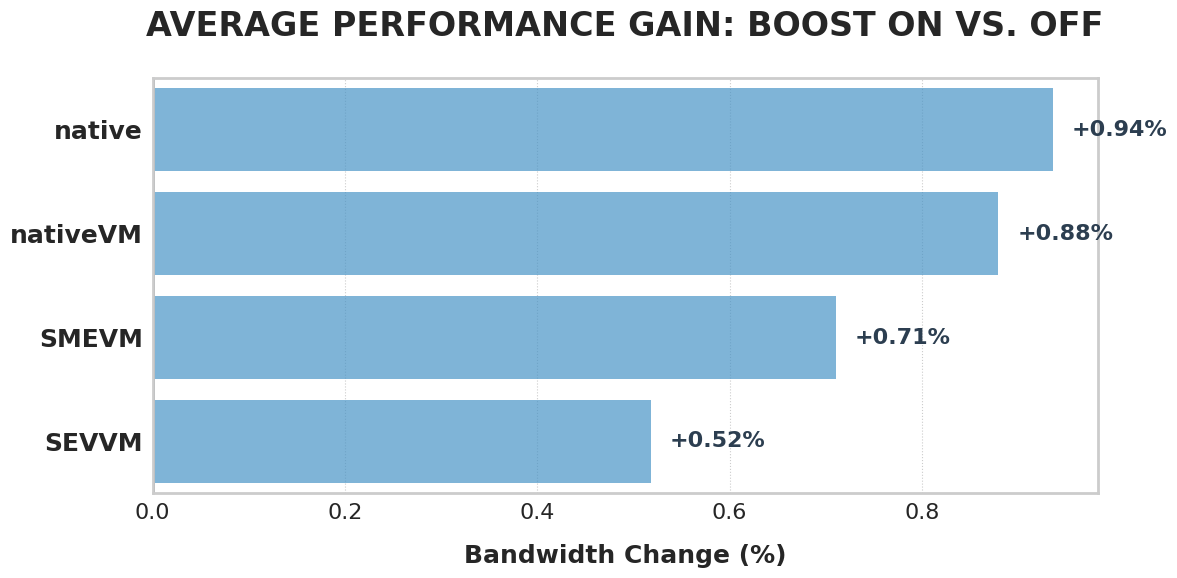

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Berechnung (Durchschnittlicher Boost-Effekt)
mean_on  = df[df["Boost"] == "on"].groupby(["Env","Threads","Numa"], observed=True)["BestRate_MBs"].mean()
mean_off = df[df["Boost"] == "off"].groupby(["Env","Threads","Numa"], observed=True)["BestRate_MBs"].mean()

pct_diff = ((mean_on - mean_off) / mean_off) * 100
pct_diff = pct_diff.reset_index(name="PctDiff")
env_diff = pct_diff.groupby("Env", observed=True)["PctDiff"].mean().reset_index()

# 2. Visualisierung
plt.figure(figsize=(12, 6))

# Wir nutzen das Hellblau (#3498db) mit alpha für Durchsichtigkeit
# hue="Env" wird gesetzt, um die Warnung zu vermeiden, palette erzwingt die Farbe
ax = sns.barplot(
    data=env_diff, 
    x="PctDiff", 
    y="Env", 
    hue="Env",
    palette=["#3498db"] * len(env_diff),
    alpha=0.7,       # <--- DURCHSICHTIGKEIT (wie im Haupt-Plot)
    legend=False,
    edgecolor=None,
    linewidth=0
)

# Titel & Achsen (Slide-Format)
plt.title("Average Performance Gain: Frequency Boost on", fontsize=24, fontweight='bold', pad=30)
plt.xlabel("Bandwidth Change (%)", fontsize=18, fontweight='bold', labelpad=15)
plt.ylabel("")

# Tick-Styling
plt.xticks(fontsize=16)
plt.yticks(fontsize=18, fontweight='bold')

# Dezente Nulllinie im Dunkelblau für den Kontrast
plt.axvline(0, color='#2c3e50', linewidth=2, linestyle='-', alpha=0.8)

# Werte direkt an die Balken schreiben
for i, p in enumerate(ax.patches):
    width = p.get_width()
    x_pos = width + (0.02 if width > 0 else -0.02)
    ha = 'left' if width > 0 else 'right'
    
    ax.text(x_pos, 
            p.get_y() + p.get_height()/2, 
            f'{width:+.2f}%', 
            va='center', 
            ha=ha,
            fontsize=16, 
            fontweight='bold', 
            color='#2c3e50')

# Rahmen des Plots dicker machen
for spine in ax.spines.values():
    spine.set_linewidth(2)

# Grid nur für die X-Achse
ax.xaxis.grid(True, linestyle=':', alpha=0.4, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()